In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
netflixdata = pd.read_csv('C:/Users/Tugsadyar/Desktop/netflix_titles.csv')
netflixdata.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
netflixdata.shape[0:2]

(8807, 12)

In [4]:
print("\nDataset Info:")
print(netflixdata.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [5]:
netflixdata['date_added'] = pd.to_datetime(netflixdata['date_added'], errors='coerce')
netflixdata['duration_num'] = np.nan
netflixdata.loc[netflixdata['type'] == 'Movie', 'duration_num'] = netflixdata.loc[netflixdata['type'] == 'Movie', 'duration'] \
    .str.replace(' min', '', regex=False).astype(float)
netflixdata.loc[netflixdata['type'] == 'TV Show', 'duration'] = netflixdata.loc[netflixdata['type'] == 'TV Show', 'duration'] \
    .str.replace(' Season', '', regex=False).str.replace('s', '', regex=False)
print(netflixdata.dtypes)

show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
duration_num           float64
dtype: object


In [6]:
print("\nMissing Values:")
print(netflixdata.isnull().sum())


Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        98
release_year       0
rating             4
duration           3
listed_in          0
description        0
duration_num    2679
dtype: int64


In [7]:
netflixdata['director'] = netflixdata['director'].fillna('Unknown')  
netflixdata['cast'] = netflixdata['cast'].fillna('Unknown')        
netflixdata['country'] = netflixdata['country'].fillna('Unknown')  

In [8]:
print("\nSummary Statistics:")
print(netflixdata.describe(include='all'))


Summary Statistics:
       show_id   type                 title director     cast        country  \
count     8807   8807                  8807     8807     8807           8807   
unique    8807      2                  8807     4529     7693            749   
top         s1  Movie  Dick Johnson Is Dead  Unknown  Unknown  United States   
freq         1   6131                     1     2634      825           2818   
mean       NaN    NaN                   NaN      NaN      NaN            NaN   
min        NaN    NaN                   NaN      NaN      NaN            NaN   
25%        NaN    NaN                   NaN      NaN      NaN            NaN   
50%        NaN    NaN                   NaN      NaN      NaN            NaN   
75%        NaN    NaN                   NaN      NaN      NaN            NaN   
max        NaN    NaN                   NaN      NaN      NaN            NaN   
std        NaN    NaN                   NaN      NaN      NaN            NaN   

                  

C:\Users\Tugsadyar\AppData\Local\Temp\ipykernel_3108\541389743.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  axis = sns.countplot(data=netflixdata, x='type', palette='pastel')


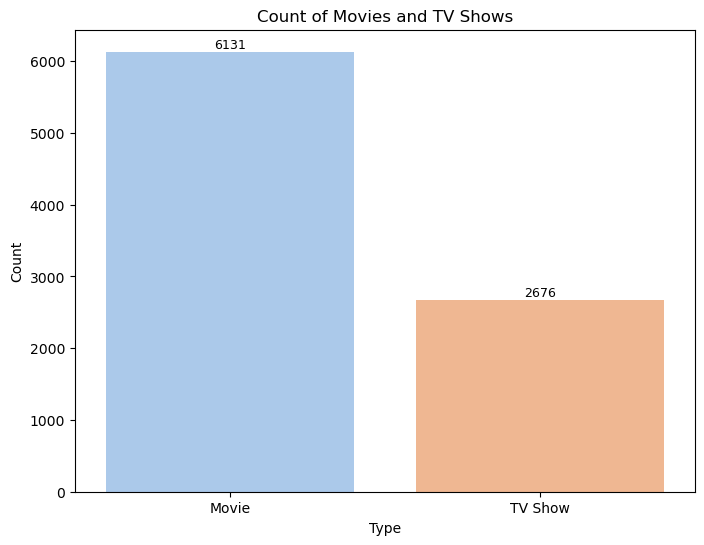

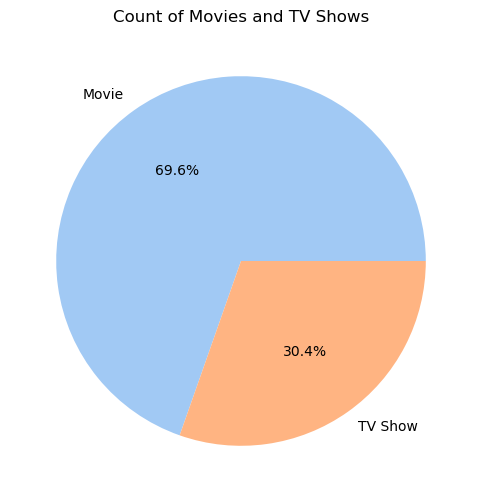

In [9]:
# Count of movies and TV shows
plt.figure(figsize=(8, 6))
axis = sns.countplot(data=netflixdata, x='type', palette='pastel')
total = len(netflixdata)

for p in axis.patches:
    count = int(p.get_height())
    percentage = 100* count / total
    axis.annotate(f"{count}",
        (p.get_x() + p.get_width()/ 2, p.get_height()),
        ha = "center",va="bottom",fontsize = 9)
plt.title('Count of Movies and TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()


type_counts = netflixdata['type'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel', n_colors=len(type_counts)))
plt.title('Count of Movies and TV Shows')
plt.show()


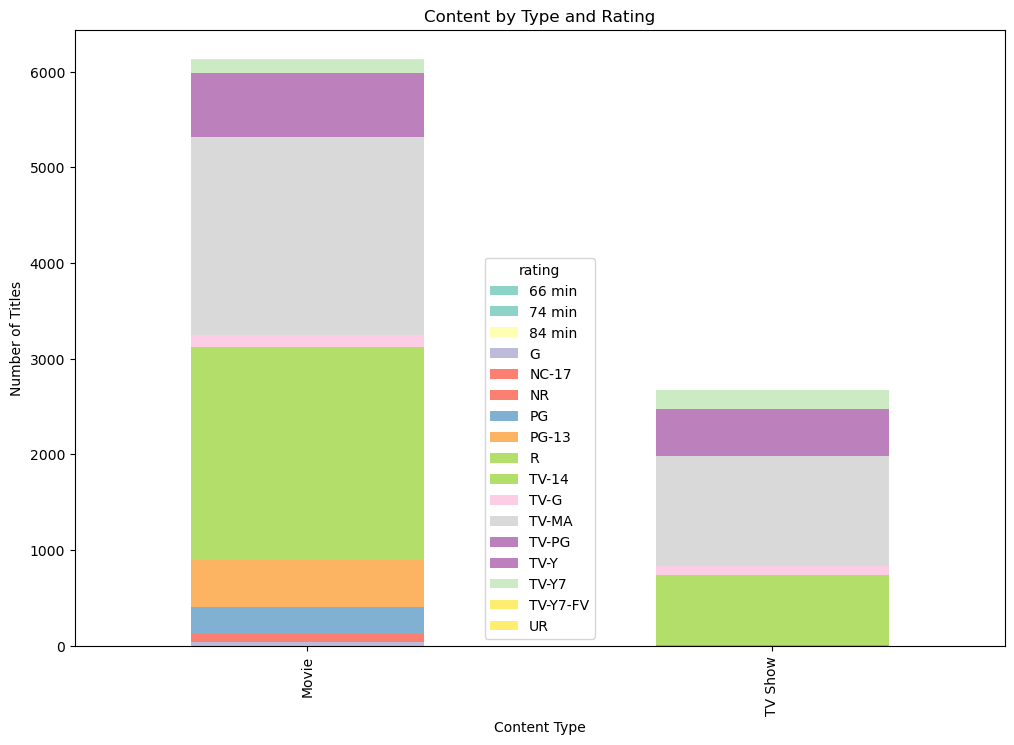

In [28]:
rating_counts = netflixdata.groupby(['type', 'rating']).size().unstack()
rating_counts.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='Set3')
plt.title('Content by Type and Rating')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.show()

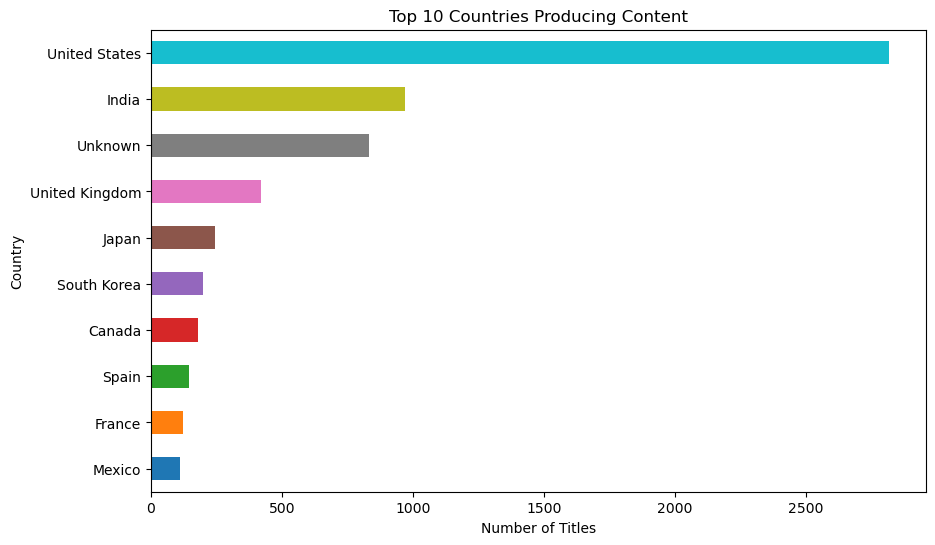

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
top_countries = netflixdata['country'].value_counts().head(10).sort_values(ascending=True)
colors = cm.tab10(range(len(top_countries)))
plt.figure(figsize=(10, 6))
top_countries.plot(kind='barh', color=colors)
plt.title('Top 10 Countries Producing Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

C:\Users\Tugsadyar\AppData\Local\Temp\ipykernel_3108\3610320118.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=netflixdata, y='rating', order=netflixdata['rating'].value_counts().index, palette='coolwarm')


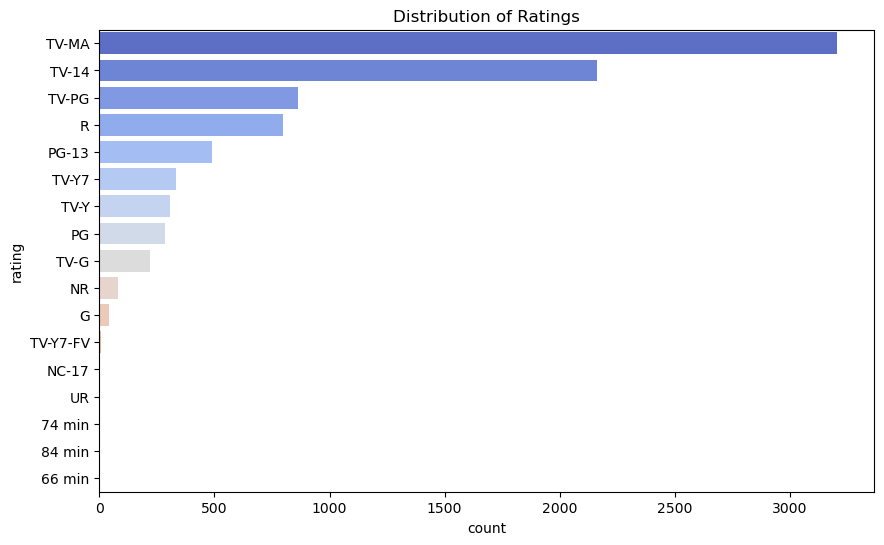

C:\Users\Tugsadyar\AppData\Local\Temp\ipykernel_3108\3610320118.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=netflixdata, x='type', y='rating', palette='muted')


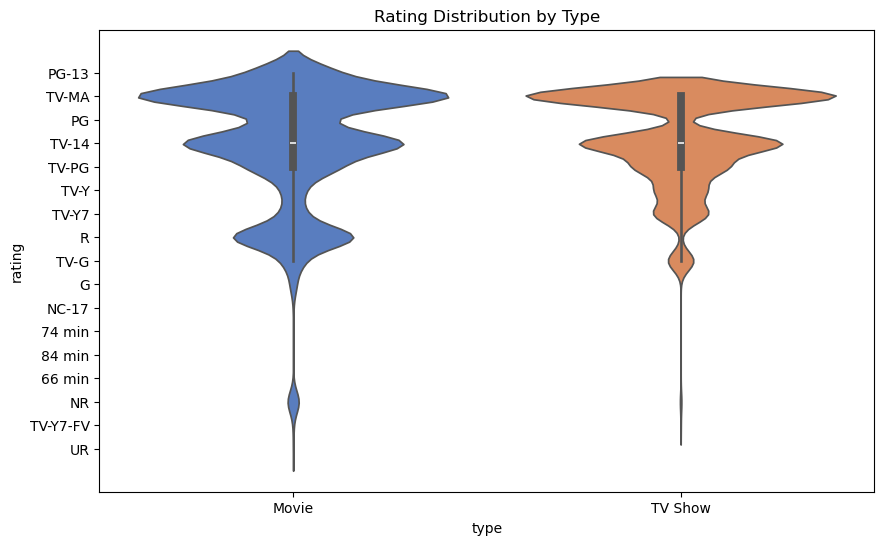

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(data=netflixdata, y='rating', order=netflixdata['rating'].value_counts().index, palette='coolwarm')
plt.title('Distribution of Ratings')
plt.show()

plt.figure(figsize=(10, 6))
sns.violinplot(data=netflixdata, x='type', y='rating', palette='muted')
plt.title('Violin plot for Distribution of Ratings')
plt.show()

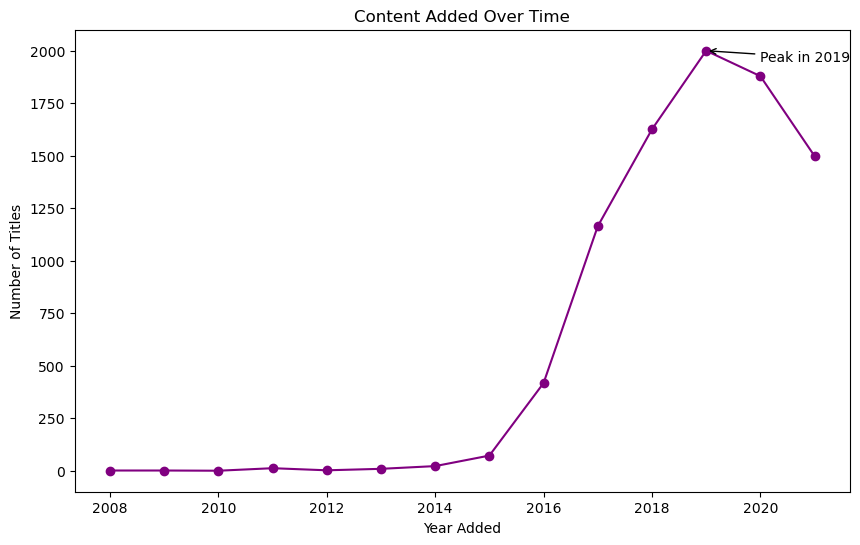

In [34]:
# Trend of content added over time
netflixdata['year_added'] = netflixdata['date_added'].dt.year
content_by_year = netflixdata['year_added'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
content_by_year.plot(kind='line', marker='o', color='purple')
peak_year = int(content_by_year.idxmax())
peak_count = int(content_by_year.max())
plt.annotate(f"Peak in {peak_year}", xy=(peak_year, peak_count), xytext=(peak_year+1, peak_count-50),
             arrowprops=dict(facecolor='black', arrowstyle="->"))
plt.title('Content Added Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

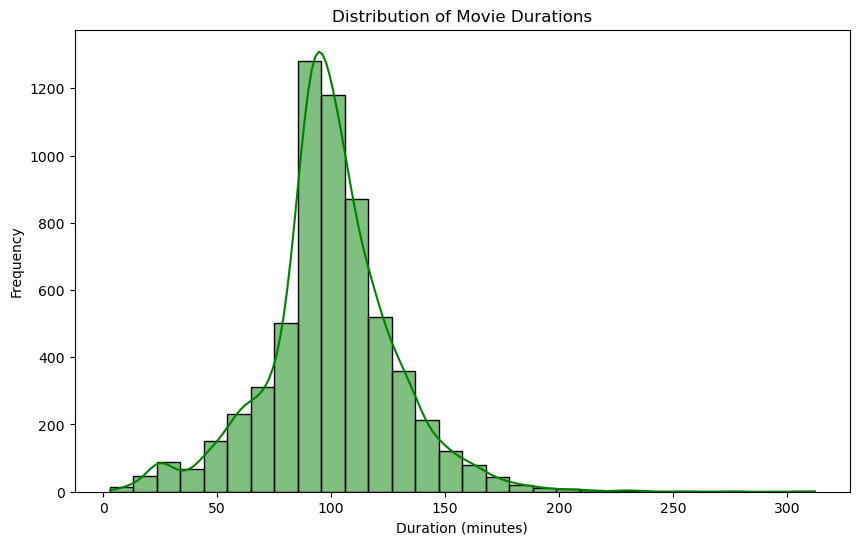

In [13]:
movie_durations = netflixdata[netflixdata['type'] == 'Movie']['duration'].dropna()
movie_durations = movie_durations.str.replace(' min', '').astype(float)
plt.figure(figsize=(10, 6))
sns.histplot(movie_durations, kde=True, bins=30, color='green')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()


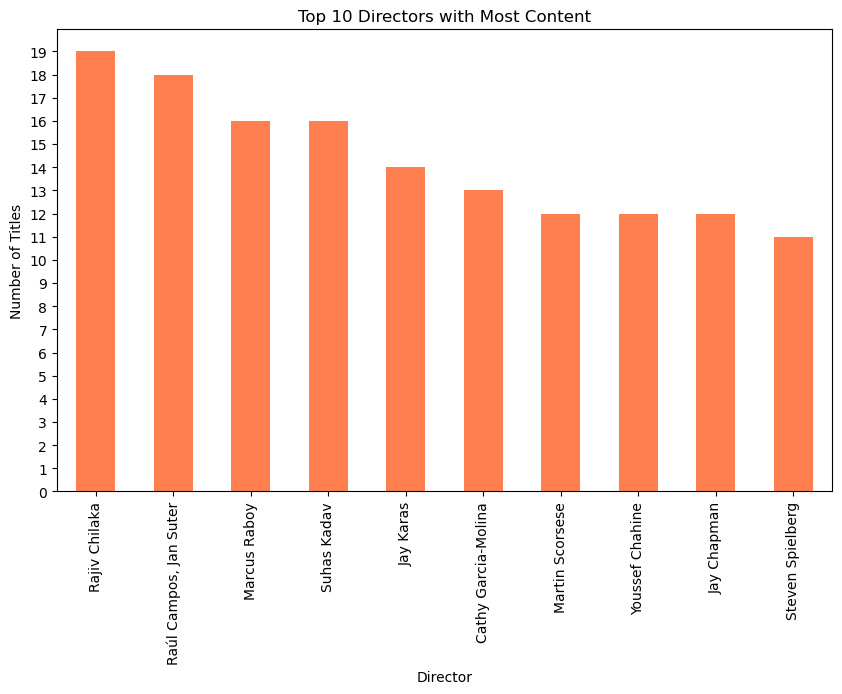

In [14]:
# Top directors with the most content
netflixdata_filtered = netflixdata[netflixdata['director'] != 'Unknown']
top_directors = netflixdata_filtered['director'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_directors.plot(kind='bar', color='coral')
plt.title('Top 10 Directors with Most Content')
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.yticks(range(0, top_directors.max() + 1, 1))
plt.show()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: object


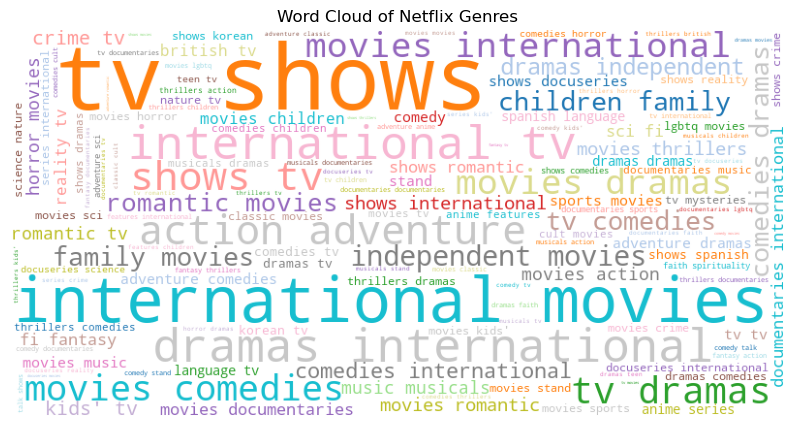

In [16]:
from wordcloud import WordCloud

# Check the column with genre-related information
print(netflixdata['listed_in'].head())  # Replace 'listed_in' with the correct column name

# Combine all genres into one large text
genres = ' '.join(netflixdata['listed_in'].dropna().str.lower())

# Create the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab20').generate(genres)

# Plot the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Word Cloud of Netflix Genres')
plt.show()


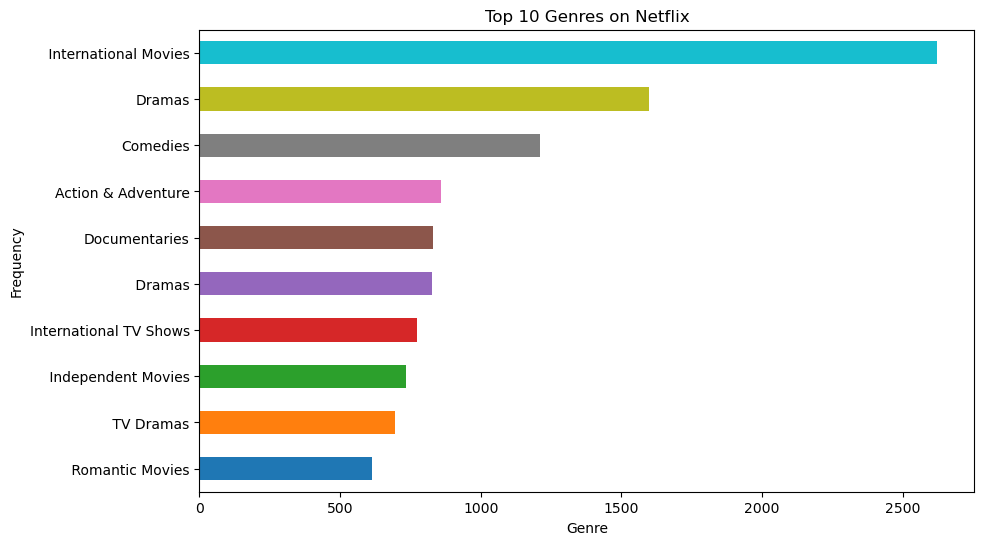

In [25]:
# Custom color list for each bar
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
top_genres = netflixdata['listed_in'].str.split(',').explode().value_counts().head(10).sort_values(ascending = True)
plt.figure(figsize=(10, 6))
top_genres.plot(kind='barh', color=colors)
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Frequency')
plt.show()


C:\Users\Tugsadyar\AppData\Local\Temp\ipykernel_3108\2656523431.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=common_words_df, palette='viridis')


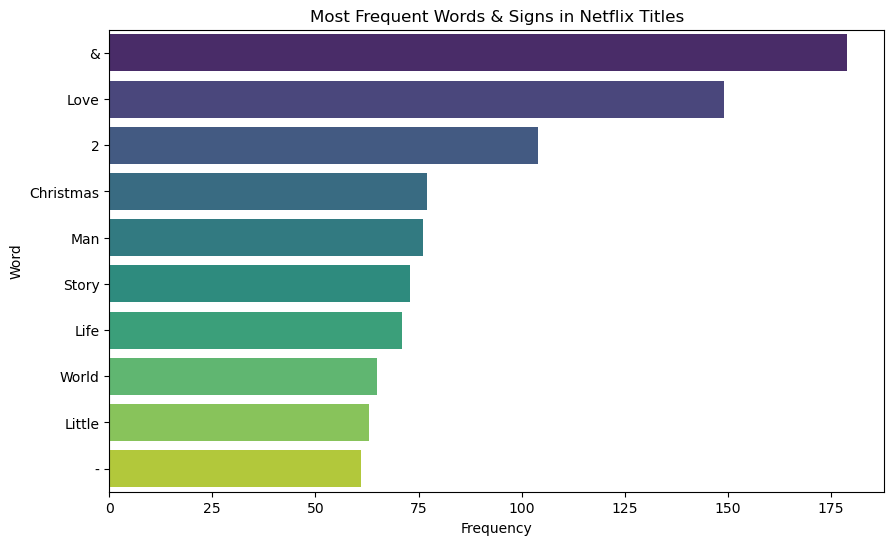

In [94]:
from wordcloud import STOPWORDS
from collections import Counter

# Extract title words and count frequencies
title_words = ' '.join(netflixdata['title'].dropna())
title_words = [word for word in title_words.split() if word.lower() not in STOPWORDS]

# Count word frequencies
word_freq = Counter(title_words)

# Plot the most common words
common_words = word_freq.most_common(10)
common_words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Word', data=common_words_df, palette='viridis')
plt.title('Most Frequent Words & Signs in Netflix Titles')
plt.show()

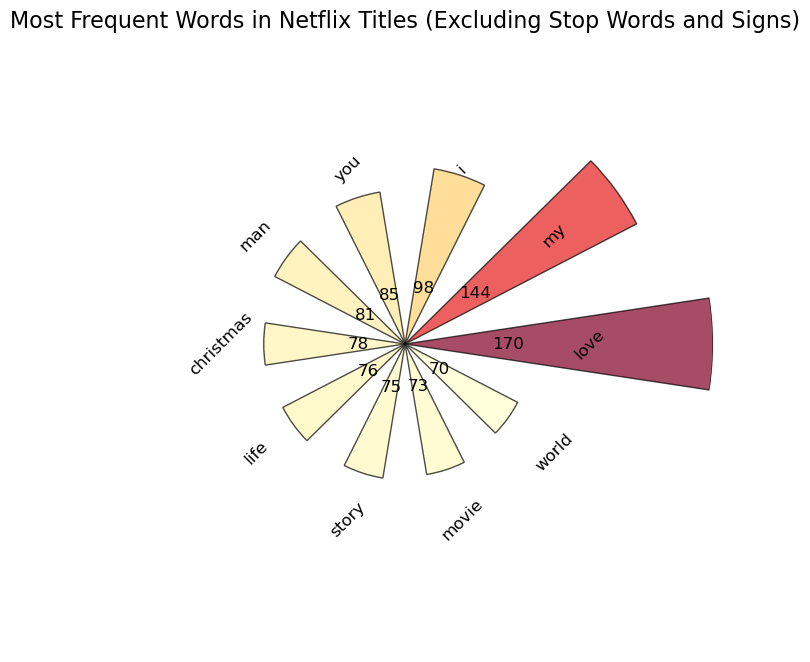

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
stop_words = {'a', 'in', 'the', 'and', 'to', 'on', 'for', 'of', 'at', 'with', 'by', 'an', 'as', 'from', 'about', 'this', 'that', 'it', 'is', 'was', 'has'}

netflixdata['title_clean'] = netflixdata['title'].str.lower().apply(lambda x: re.sub(r'[^a-z\s]', '', x))

all_words = ' '.join(netflixdata['title_clean']).split()
filtered_words = [word for word in all_words if word not in stop_words]
most_common_words = word_counts.most_common(10)
most_common_words.sort(key=lambda x: x[1], reverse=True)


words, counts = zip(*most_common_words)
num_vars = len(words)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
counts = list(counts)
counts += counts[:1]
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colormap = plt.cm.YlOrRd
norm = plt.Normalize(vmin=min(counts), vmax=max(counts))
for i, (angle, count) in enumerate(zip(angles, counts[:-1])):
    color = colormap(norm(count))
    ax.bar(angle, count, width=0.3, bottom=0.0, color=color, edgecolor='black', alpha=0.7)
ax.set_yticklabels([]) 
ax.set_xticks([]) 
ax.grid(False)  
ax.set_ylim(0, max(counts)) 
ax.spines['polar'].set_visible(False)

for i, (word, count) in enumerate(zip(words, counts[:-1])):
    ax.text(angles[i], count /3, str(count), ha='center', va='center', fontsize=12, color='black')
    
for i, (word, angle) in enumerate(zip(words, angles[:-1])):
    ax.text(angle, max(counts) /1.67 , word, ha='center', va='center', fontsize=12, color='black', rotation=45)

ax.set_xticks([])
ax.set_yticks([])
ax.set_rticks([])

plt.title('Most Frequent Words in Netflix Titles (Excluding Stop Words and Signs)', size=16)

plt.show()